In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemblemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [3]:
df = pd.read_csv("C:/Users/niles/OneDrive/Desktop/BE(CS)/ML/DATA_SET/uber.csv")

In [4]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [6]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [7]:
df.shape

(200000, 9)

In [8]:
df = df.drop(['Unnamed: 0','key'], axis = 1)

In [9]:
df.shape

(200000, 7)

In [10]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [11]:
df.isnull()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
199995,False,False,False,False,False,False,False
199996,False,False,False,False,False,False,False
199997,False,False,False,False,False,False,False
199998,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [13]:
df.isnull().sum().sum()

2

In [14]:
dropoff_longitude_mean = df["dropoff_longitude"].mean()
df["dropoff_longitude"].fillna(dropoff_longitude_mean,inplace=True)
dropoff_latitude_mean = df["dropoff_latitude"].mean()
df["dropoff_latitude"].fillna(dropoff_latitude_mean,inplace=True)

In [15]:
df.isnull().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [16]:
df.isnull().sum().sum()

0

In [17]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])  # Convert to datetime

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   fare_amount        200000 non-null  float64            
 1   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 2   pickup_longitude   200000 non-null  float64            
 3   pickup_latitude    200000 non-null  float64            
 4   dropoff_longitude  200000 non-null  float64            
 5   dropoff_latitude   200000 non-null  float64            
 6   passenger_count    200000 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(1)
memory usage: 10.7 MB


In [19]:
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek  # Feature extraction
df['hour'] = df['pickup_datetime'].dt.hour

In [20]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,day_of_week,hour
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,3,19
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,4,20
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0,21
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,4,8
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,3,17
...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,6,10
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,4,1
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,0,0
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2,14


In [21]:
def haversine(lon1,lon2,lat1,lat2):
    lon1,lon2,lat1,lat2 = map(np.radians,[lon1,lon2,lat1,lat2])
    diff_lon = lon2 - lon1
    diff_lat = lat2 - lat1
    a = np.sin(diff_lat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(diff_lon/2)**2
    km = 2 * 6371 * np.arcsin(np.sqrt(a),np.sqrt(1 - a))
    return km

In [22]:
df['distance'] = haversine(df['pickup_longitude'],df['dropoff_longitude'],df['pickup_latitude'],df['dropoff_latitude'])

In [23]:
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,day_of_week,hour,distance
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,3,19,1.683323
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,4,20,2.457590
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,0,21,5.036377
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,4,8,1.661683
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,3,17,4.475450
...,...,...,...,...,...,...,...,...,...,...
199995,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,6,10,0.112210
199996,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,4,1,1.875050
199997,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,0,0,12.850319
199998,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2,14,3.539715


fare_amount             AxesSubplot(0.125,0.772143;0.352273x0.107857)
pickup_longitude     AxesSubplot(0.547727,0.772143;0.352273x0.107857)
pickup_latitude         AxesSubplot(0.125,0.642714;0.352273x0.107857)
dropoff_longitude    AxesSubplot(0.547727,0.642714;0.352273x0.107857)
dropoff_latitude        AxesSubplot(0.125,0.513286;0.352273x0.107857)
passenger_count      AxesSubplot(0.547727,0.513286;0.352273x0.107857)
day_of_week             AxesSubplot(0.125,0.383857;0.352273x0.107857)
hour                 AxesSubplot(0.547727,0.383857;0.352273x0.107857)
distance                AxesSubplot(0.125,0.254429;0.352273x0.107857)
dtype: object

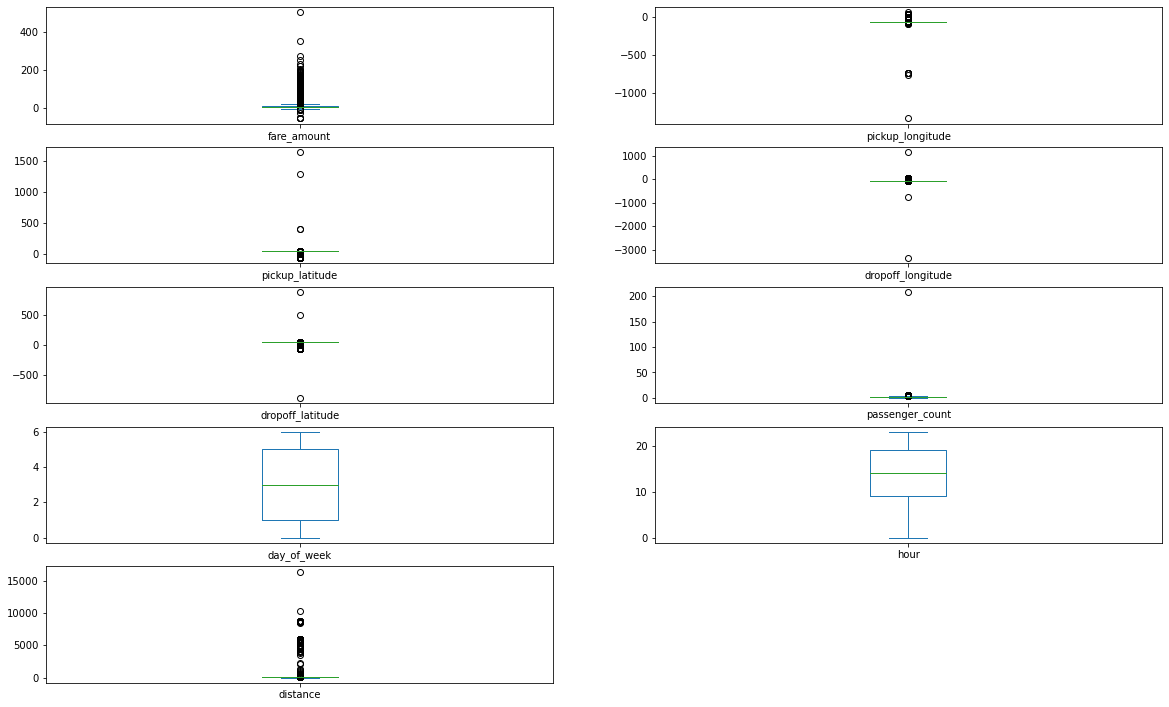

In [125]:
df.plot(kind="box",subplots="true",layout=(6,2),figsize=(20,15))

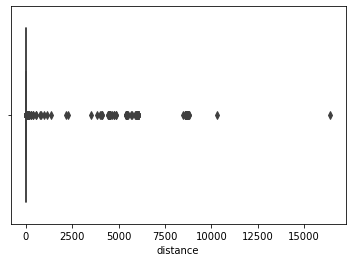

In [126]:
sns.boxplot(x=df['distance'])
plt.show()

In [127]:
q1 = np.percentile(df["distance"],25)
q3 = np.percentile(df["distance"],75)
print(q1,q3)

1.2152224967011795 3.8752477333254265


In [128]:
IQR = q3-q1

In [129]:
lwr_bound = q1 - (1.5*IQR)
upr_bound = q3 + (1.5*IQR)
print(lwr_bound,upr_bound)

-2.774815358235191 7.865285588261797


In [130]:
distance_mean = df["distance"].mean()

In [131]:
df["distance"] = np.where(df["distance"]>upr_bound,distance_mean,df["distance"])

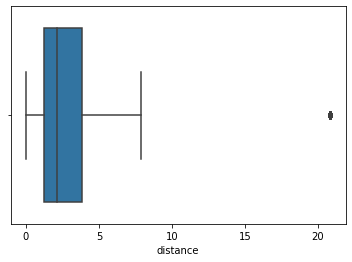

In [132]:
sns.boxplot(x=df['distance'])
plt.show()

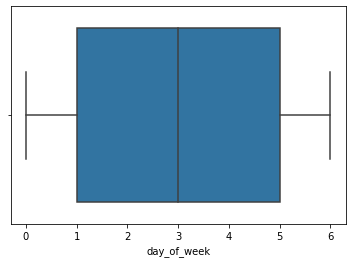

In [133]:
sns.boxplot(x=df['day_of_week'])
plt.show()

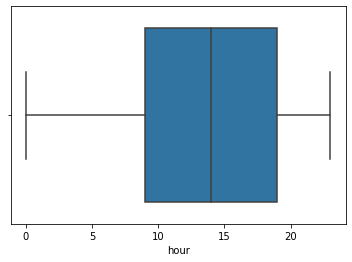

In [134]:
sns.boxplot(x=df['hour'])
plt.show()

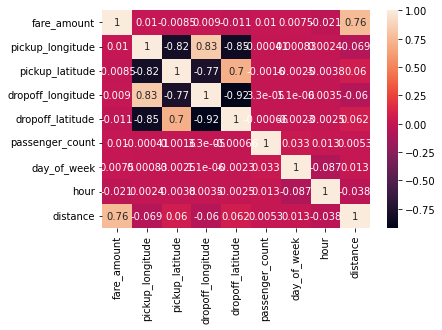

In [135]:
# Visualize correlation matrix
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True,)
plt.show()

In [136]:
x = df[['distance','hour','day_of_week']]
y = df['fare_amount']

In [137]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.25,random_state=42)

In [138]:
lgm = LinearRegression()
model = lgm.fit(x_train,y_train)

In [139]:
y_pred = lgm.predict(x_test)

In [140]:
result = pd.DataFrame()
result['Actual'], result['Predicted'] = y_test, y_pred
result.sample(5)

,Actual,Predicted
107439,19.3,16.846116
65248,4.9,7.255101
21004,12.9,10.908344
67752,9.5,8.150947
28741,5.7,8.054513


In [141]:
rfm = RandomForestRegressor()
model = rfm.fit(x_train,y_train)

In [142]:
y_pred1 = rfm.predict(x_test)

In [143]:
result1 = pd.DataFrame()
result1['Actual'], result1['Predicted'] = y_test, y_pred1
result1.sample(5)

,Actual,Predicted
118618,6.50,8.499
175108,49.57,9.590
88555,9.70,12.868
51907,15.30,7.697
193541,6.10,8.128


In [144]:
print("*** Linear Regression *** ")
print("R Squared               : ",r2_score(y_test,y_pred))
print("Root Mean Squared Error : ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("Mean Absolute Error     : ",mean_absolute_error(y_test,y_pred))

*** Linear Regression *** 
R Squared               :  0.539543927869164
Root Mean Squared Error :  6.879753250945323
Mean Absolute Error     :  3.2426866155586804


In [145]:
print("*** Random Forest Regression *** ")
print("R Squared               : ",r2_score(y_test,y_pred1))
print("Root Mean Squared Error : ",np.sqrt(mean_squared_error(y_test,y_pred1)))
print("Mean Absolute Error     : ",mean_absolute_error(y_test,y_pred1))

*** Random Forest Regression *** 
R Squared               :  0.5610444982767602
Root Mean Squared Error :  6.71721127418028
Mean Absolute Error     :  3.0807355161467074
